# Tips Dataset EDA

Applying all the knowledge behind the notebooks we have previously covered (Data Insights, Data Cleaning and Preprocessing, and Feature Engineering and Selection), we will make a full EDA on various example-Datasets. 

For this notebook, we will run an EDA on the `seaborn` library tips dataset, a dataset with a balanced ammount of numerical and categorical variables, to tackle what EDA's generally look like in datasets similar to these, which are relatively common in real-life scenarios.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import textblob
import spacy
import gensim
import umap.umap_ as umap
from sklearn.feature_selection import SelectKBest, f_regression

## Loading the dataset

First and foremost, we need to load the dataset and do a quick check of its contents, to see if at first sight there is any issues with the import process:

In [4]:
tips = sns.load_dataset('tips')
tips.head()
#tips.info()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


From the official [source link](https://rdrr.io/cran/reshape2/man/tips.html) and as a result of the command `info`, we have 7 features:

- **`total_bill`:** a numerical variable representing the bill on that particular entry in dollars;
- **`tip`:** As the name suggests, a numerical variable representing the tip that was given in dollars;
- **`sex`:** Categorical variable, which represents the gender of the bill payer;
- **`smoker`:** Categorical binary variable, signaling whether there were any smokers in the party;
- **`day`:** Categorical variable that is a truncation of the weekday of the visit;
- **`time`:** Categorical variable that represents which meal the bill refers to;
- **`size`:** Numerical variable representing the size of the party

## Initial Data Inspection

Now we can run some initial observations to get some insights on this dataset:

In [5]:
print(tips.describe())

       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [6]:
# Check for missing values
print(tips.isnull().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [11]:
Z_bill = stats.zscore(tips['total_bill'])
Z_tip = stats.zscore(tips['tip'])

outliers_bill = tips[(Z_bill < -3) | (Z_bill > 3)]
outliers_tip = tips[(Z_tip < -3) | (Z_tip > 3)]

print("Estimated outliers in total_bill: ", outliers_bill)
print("Estimated outliers in tip: ", outliers_tip)

Estimated outliers in total_bill:       total_bill    tip   sex smoker  day    time  size
59        48.27   6.73  Male     No  Sat  Dinner     4
156       48.17   5.00  Male     No  Sun  Dinner     6
170       50.81  10.00  Male    Yes  Sat  Dinner     3
212       48.33   9.00  Male     No  Sat  Dinner     4
Estimated outliers in tip:       total_bill    tip   sex smoker  day    time  size
23        39.42   7.58  Male     No  Sat  Dinner     4
170       50.81  10.00  Male    Yes  Sat  Dinner     3
212       48.33   9.00  Male     No  Sat  Dinner     4


There is no need for imputation due to missing values, which is good. But keep in mind that usually the case is that there are going to be missing values that need to be addressed. When talking about outliers, it makes sense to run an analysis on the bill and tip columns. The results show that using the `z-score evaluation` gives 4 outliers in the `bill` column and 3 outliers in the `tip` column, where there are 2 that intersect. Due to the overall nature of this dataset and the fact that it is few examples, it will be more fruitful to maintain these outliers in the dataset.

## Univariate Analysis

Now we run some more detailed observations on the numerical and categorical data:

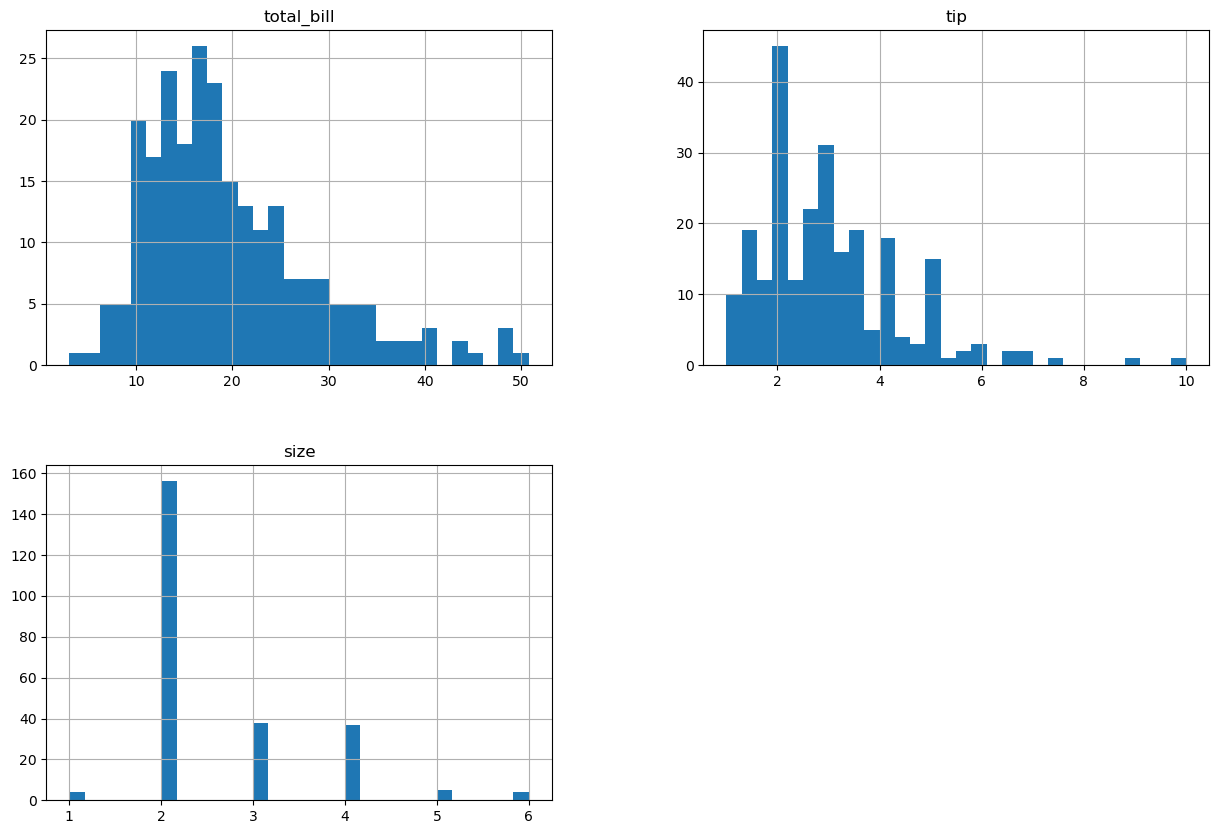

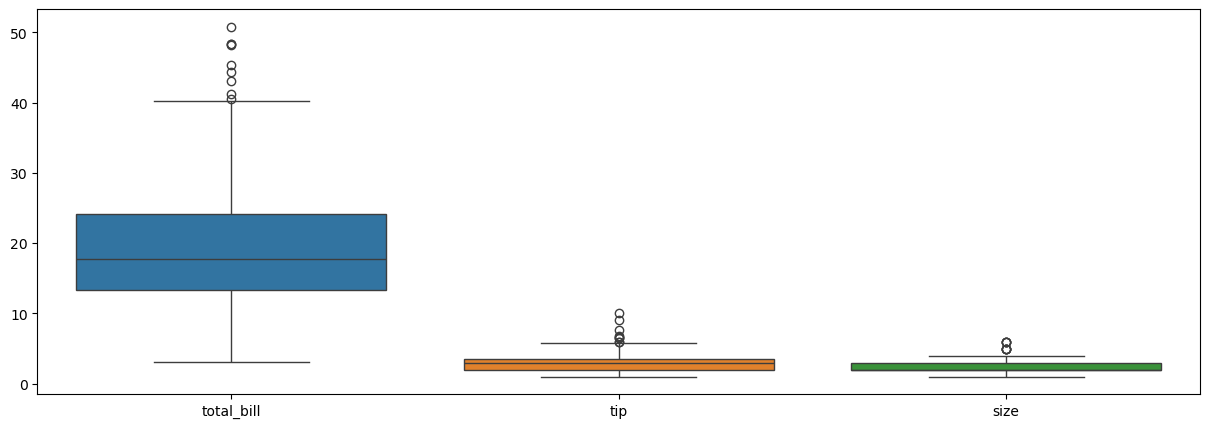

In [12]:
# Histograms for numerical features
tips.hist(bins=30, figsize=(15, 10))
plt.show()

# Boxplots for numerical features
plt.figure(figsize=(15, 5))
sns.boxplot(data=tips.select_dtypes(include=['float64', 'int64']))
plt.show()

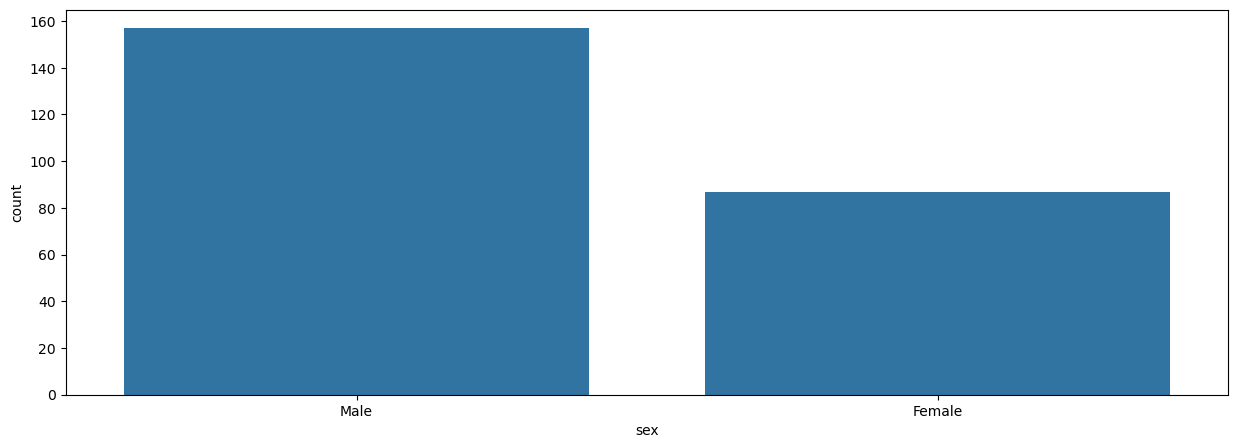

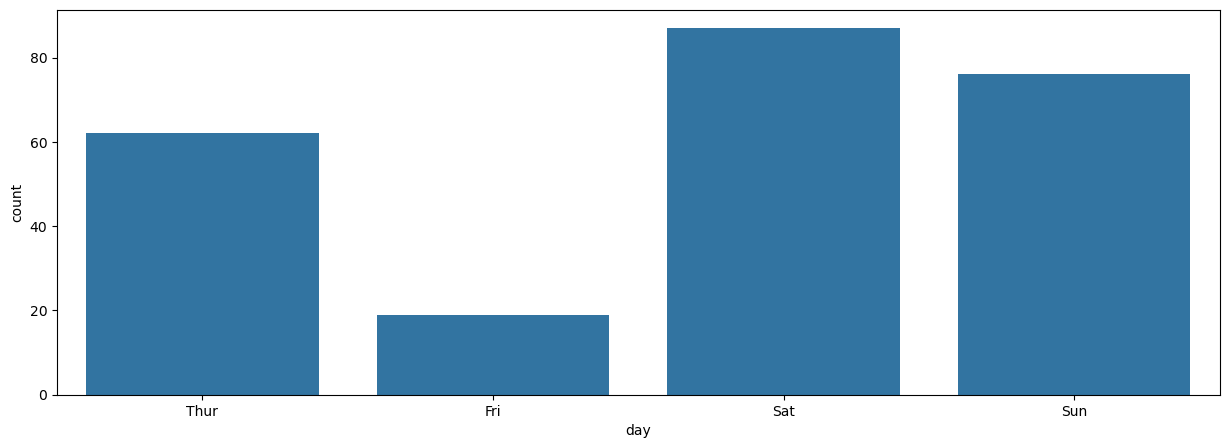

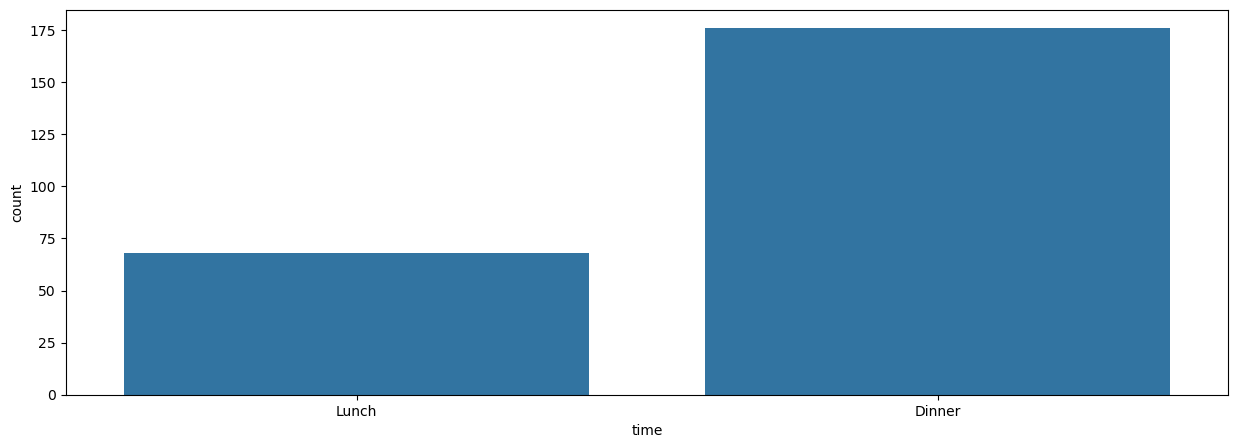

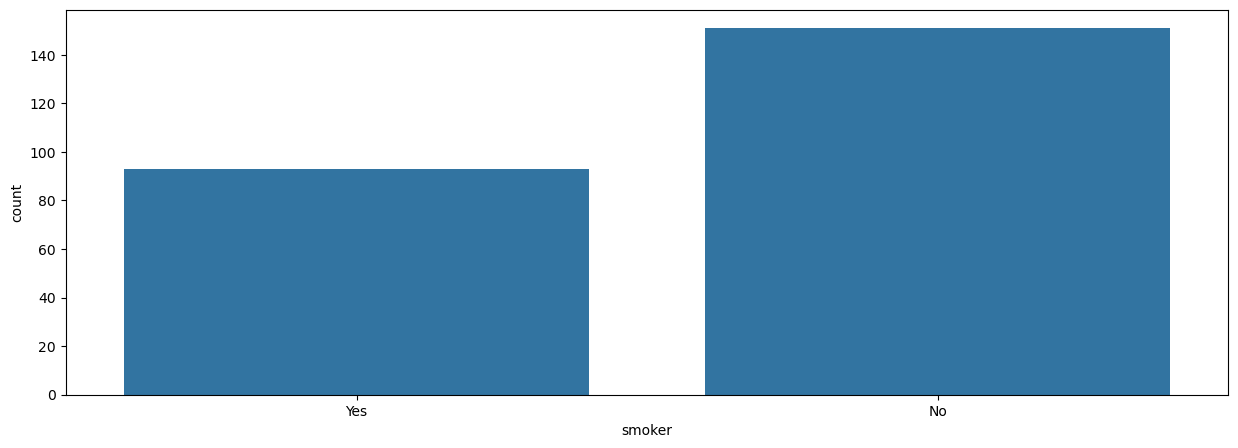

In [13]:
# Count plots for categorical features
plt.figure(figsize=(15, 5))
sns.countplot(data=tips, x='sex')
plt.show()

plt.figure(figsize=(15, 5))
sns.countplot(data=tips, x='day')
plt.show()

plt.figure(figsize=(15, 5))
sns.countplot(data=tips, x='time')
plt.show()

plt.figure(figsize=(15, 5))
sns.countplot(data=tips, x='smoker')
plt.show()